In [1]:
import matplotlib.pyplot as plt
import torch
import gymnasium as gym
import imageio
import dill
import numpy as np
import pandas as pd
from dataclasses import make_dataclass
import seaborn as sns
from copy import deepcopy
from matplotlib.widgets import Slider

from four_room.env import FourRoomsEnv
from four_room.constants import train_config, size
from four_room.wrappers import gym_wrapper
gym.register('MiniGrid-FourRooms-v1', FourRoomsEnv)

%matplotlib qt
%load_ext autoreload
%autoreload 2

In [2]:

def plot_map(file_name: str, env_ids: int):
    env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )        
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    
    with open(f'results/dqn_exps/{file_name}.pl', 'rb') as file:
        results = dill.load(file)

    for idx, ax in enumerate(axes.flat):
        matrix = results['heatmap'][env_ids[idx]]
        colors = np.full((19, 19), np.nan, dtype=float)

        colors[0, :] = 0
        colors[-1, :] = 0
        colors[:, 0] = 0
        colors[:, -1] = 0

        colors[9, :] = 0
        colors[:, 9] = 0
        
        env.get_wrapper_attr('set_context')(env_ids[idx])
        _, _ = env.reset()
        start_pos, doors_pos, goal_pos = env.get_wrapper_attr('context_info')(env_ids[idx])
        
        room_w = 19//2
        room_h = 19//2
        
        highlight_cells = []
        for j in range(0, 2):
            for i in range(0, 2):
                xL = i * room_w
                yT = j * room_h
                xR = xL + room_w
                yB = yT + room_h

                if i + 1 < 2:
                    pos = (xR, yT + 1 + doors_pos[j])
                    highlight_cells.append(pos)

                if j + 1 < 2:
                    pos = (xL + 1 + doors_pos[2 + i], yB)
                    highlight_cells.append(pos)
        
        colors[start_pos[0], start_pos[1]] = 1
        colors[goal_pos[0], goal_pos[1]] = 2

        for r, c in highlight_cells:
            colors[r, c] = np.nan

        matrix_data = deepcopy(matrix).astype(str)
        for r in range(matrix_data.shape[0]):
            for c in range(matrix_data.shape[1]):
                matrix_data[r, c] = str(int(matrix[r, c]))
                
        matrix_data[start_pos[0], start_pos[1]] = 'Start'
        matrix_data[goal_pos[0], goal_pos[1]] = 'Goal'
        
        sns.heatmap(matrix, cmap='magma', annot=matrix_data, cbar_kws={'label': 'Number of switches'}, ax=ax, fmt='')

        overlay_cmap = sns.color_palette(["grey", "red", "lime"])
        sns.heatmap(colors, cmap=overlay_cmap, mask=np.isnan(colors), cbar=False, alpha=0.6, ax=ax)
        ax.set_title(f"H0eatmap Env {env_ids[idx]}")

    plt.tight_layout()
    plt.show()

    env.close()

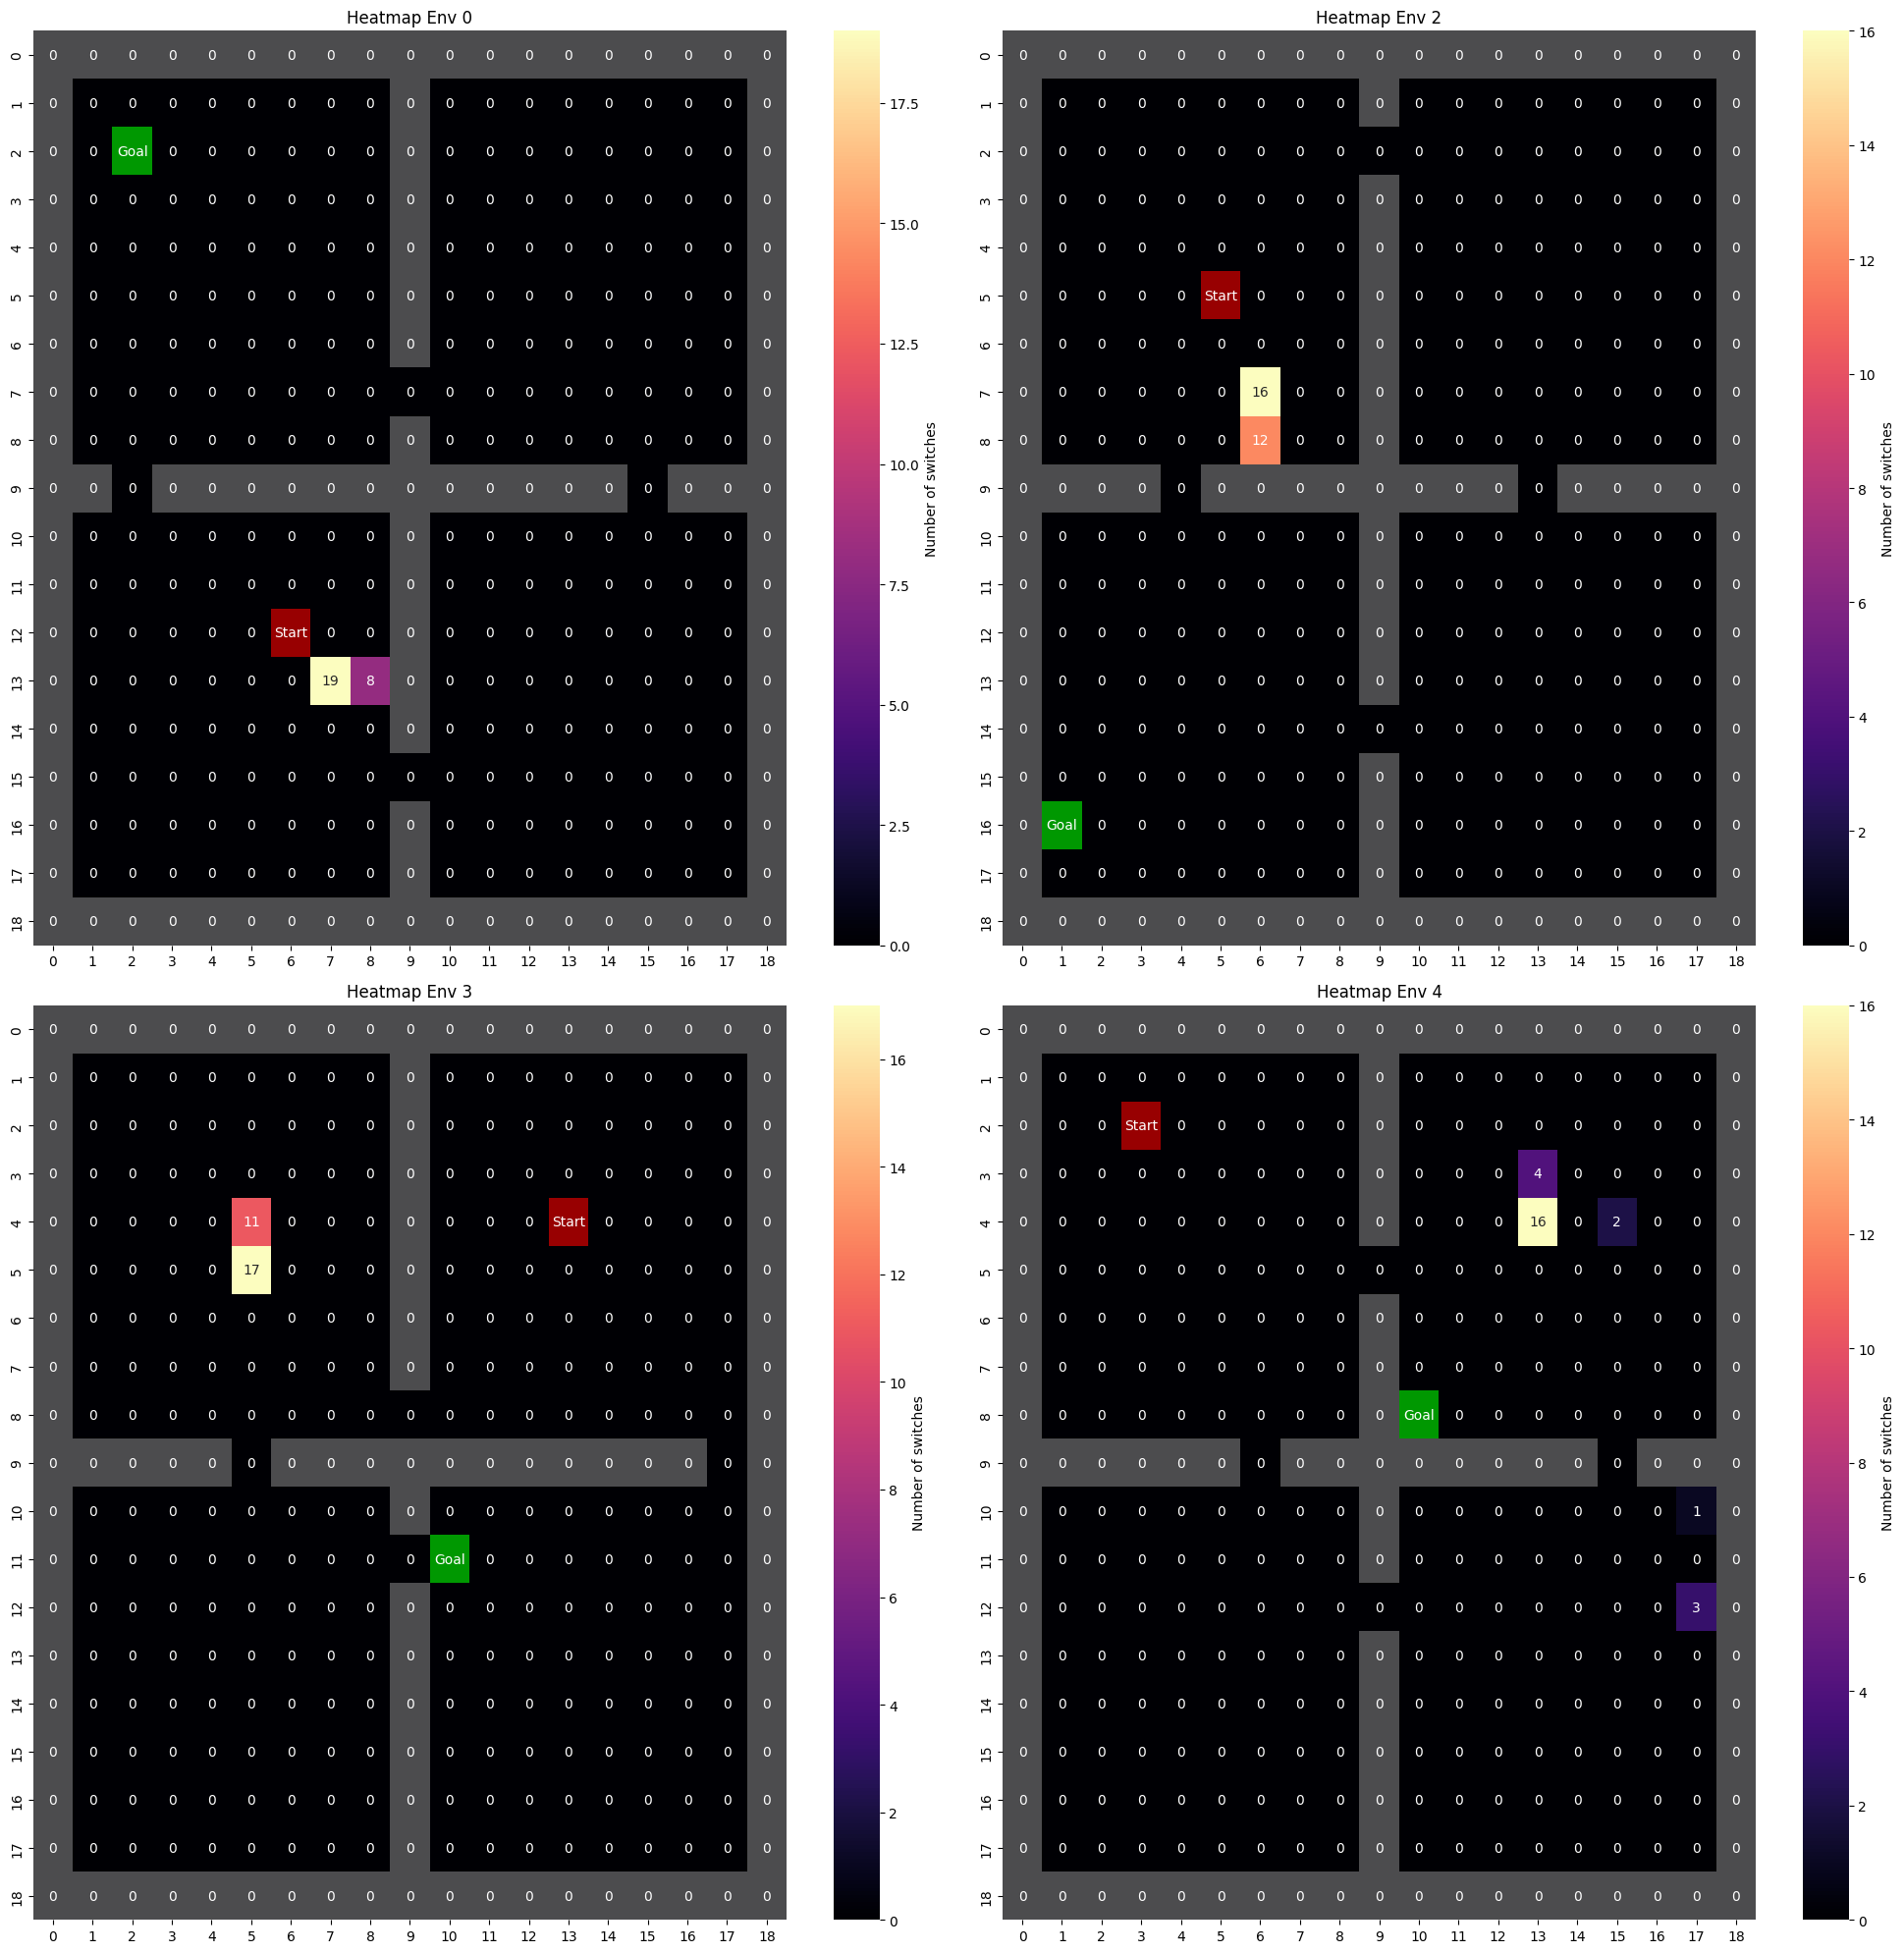

In [5]:
plot_map('basic_count_fixed_seed_0_100000', [0, 2, 3, 4])

In [3]:
def plot_env_heatmap(results, context_info: tuple, label: str, title: str, ax=None, annot: bool = True):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    matrix = results
    colors = np.full((19, 19), np.nan, dtype=float)

    colors[0, :] = 0
    colors[-1, :] = 0
    colors[:, 0] = 0
    colors[:, -1] = 0
    colors[9, :] = 0
    colors[:, 9] = 0

    start_pos, doors_pos, goal_pos = context_info

    room_w = 19 // 2
    room_h = 19 // 2

    highlight_cells = []
    for j in range(2):
        for i in range(2):
            xL = i * room_w
            yT = j * room_h
            xR = xL + room_w
            yB = yT + room_h

            if i + 1 < 2:
                pos = (xR, yT + 1 + doors_pos[j])
                highlight_cells.append(pos)

            if j + 1 < 2:
                pos = (xL + 1 + doors_pos[2 + i], yB)
                highlight_cells.append(pos)

    colors[start_pos[0], start_pos[1]] = 1
    colors[goal_pos[0], goal_pos[1]] = 2

    for r, c in highlight_cells:
        colors[r, c] = np.nan

    matrix_data = deepcopy(matrix).astype(str)
    for r in range(matrix_data.shape[0]):
        for c in range(matrix_data.shape[1]):
            matrix_data[r, c] = str(int(matrix[r, c]))

    matrix_data[start_pos[0], start_pos[1]] = 'Start'
    matrix_data[goal_pos[0], goal_pos[1]] = 'Goal'

    sns.heatmap(
        matrix,
        cmap='magma',
        annot=matrix_data if annot else False,
        cbar_kws={'label': label},
        ax=ax,
        xticklabels=False, 
        yticklabels=False,
        fmt=''
    )

    overlay_cmap = sns.color_palette(["grey", "red", "lime"])
    sns.heatmap(
        colors,
        cmap=overlay_cmap,
        mask=np.isnan(colors),
        cbar=False,
        alpha=0.6,
        xticklabels=False, 
        yticklabels=False,
        ax=ax
    )

    ax.set_title(f"{title}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    return ax

def find_states(history: list, timestep: int, capacity: int):
    states = []
    begin = timestep - capacity if timestep > capacity else 0
    
    for i in range(len(history)):
        step, context, x, y = history[i]    
        if begin <= step-1 <= timestep:
            states.append((context, x, y))
    
    return states

In [10]:
def plot_timestep(file_name: str, timestep: int, annot_expl: bool = True, remove_dir: bool = True):
    with open(f'results/dqn_exps/{file_name}.pl', 'rb') as file:
        results = dill.load(file)
        
    env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )  
    
    # get switches
    switch_history = results['switch_states']
    buffer_switch_counts = np.zeros_like(results['heatmap'])
    buffer_moving = results['counter_moving']
    buffer_full = results['counter_full']
    full_switches = results['heatmap']
    explored_states = results['explore_heatmap']
    aux_states = results['aux_heatmap']
    
    relevant_switches = find_states(switch_history, timestep, buffer_moving.capacity)
    for switch in relevant_switches:
        buffer_switch_counts[*switch] += 1
    
    relevant_buffer_states = find_states(buffer_moving.all_states, timestep, buffer_moving.capacity)
    relevant_buffer = np.zeros_like(aux_states)
    for state in relevant_buffer_states:
        relevant_buffer[*state] += 1
        
    context = results['context_history'][timestep]
    context_info = env.get_wrapper_attr('context_info')(context)
    
    fig, axes = plt.subplots(3, 2, figsize=(20, 20))
    # moving switch count
    plot_env_heatmap(buffer_switch_counts[context], context_info,
                     'Switch Counts', f'Switches Heatmap for context {context}', axes[0, 0]) 
    # moving buffer count
    plot_env_heatmap(relevant_buffer[context], context_info, 
                     'Buffer Counts', f'Buffer Heatmap for context {context}', axes[0, 1]) 
    # full switches
    plot_env_heatmap(full_switches[context], context_info, 
                     'Switch Counts (full)', f'Switches Heatmap (full) for context {context}', axes[1, 0]) 
    # full buffer
    plot_env_heatmap(buffer_full.counts_matrix[context], context_info, 
                     'Buffer Counts (full)', f'Buffer Heatmap (full) for context {context}', axes[1, 1])
    # explored states 
    plot_env_heatmap(explored_states[context], context_info, 
                     'Explore Counts', f'Explored States (full) for context {context}', axes[2, 0], annot=annot_expl) 
    # aux selected states
    plot_env_heatmap(aux_states[context], context_info, 
                     'Aux Counts', f'Aux Selected Heatmap (full) for context {context}', axes[2, 1], annot=annot_expl)
    
    env.close()
    
    return (fig, axes)

In [174]:
env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )

In [176]:
print(env.get_wrapper_attr('context'))

0


0
0
((12, 6), (1, 5, 6, 5), (2, 2))


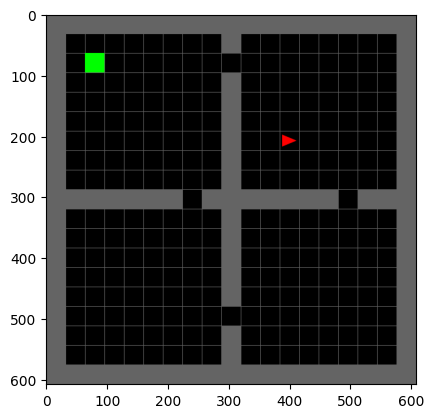

In [168]:
env.get_wrapper_attr('set_context')(0)
print(env.get_wrapper_attr('context'))
print(env.unwrapped.context)
print(env.get_wrapper_attr('context_info')(0))
env.reset()
plt.imshow(env.unwrapped.render());

In [10]:
with open(f'results/dqn_exps/dqn_count_test_seed_0_1000.pl', 'rb') as file:
    results = dill.load(file)

In [ ]:
import plotly.graph_objects as go

def plot_interactive_timesteps(file_name: str, timesteps: list[int], annot_expl: bool = True):
    figs_axes = [plot_timestep(file_name, t, annot_expl=annot_expl) for t in timesteps]
    figs = [f for f, _ in figs_axes]
    figs[0].canvas.draw_idle()
    
    ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
    slider = Slider(ax_slider, 'Timestep', 0, len(figs) - 1, valinit=0, valstep=1)
    
    def update(val):
        idx = int(slider.val)
        figs[idx].canvas.draw_idle()
        
    slider.on_changed(update)
    plt.show()

In [ ]:
plot_interactive_timesteps('basic_count_fixed_moving_seed_0_100000', [10, 11, 12, 13])

Generating 4 matplotlib figures...
  Processing timestep 10 (1/4)
  Processing timestep 11 (2/4)
  Processing timestep 12 (3/4)
  Processing timestep 13 (4/4)
Done! Use the slider to navigate between timesteps.
